5장 성능 향상

In [ ]:
# 예제 5.1 파라미터 수

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense

inputs = Input(shape=(4096, ))   # 입력층 뉴런 4,096개
x = Dense(4096, activation="relu")(inputs)   # 은닉층 뉴런 4,096개
outputs = Dense(1000, activation="softmax")(x)   # 출력층 뉴런 1,000개

model = Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4096)                │      16,781,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1000)                │       4,097,000 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,878,312 (79.64 MB)

 Trainable params: 20,878,312 (79.64 MB)

 Non-trainable params: 0 (0.00 B)

In [1]:
# 예제 5.2 이미지 증강 Cats_and_Dogs(다운로드 후 압축 해제)

# 셋업
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
import matplotlib.pyplot as plt
import gdown
import zipfile
from PIL import Image

# 데이터셋 다운로드
url = "https://storage.googleapis.com/mledu-datasets" \
      "/cats_and_dogs_filtered.zip"
zip_path = "cats_and_dogs_filtered.zip"

gdown.download(url, zip_path, quiet=False)   # 다운로드

with zipfile.ZipFile(zip_path, 'r') as zip_file:   # 압축 해제
    file_path = zip_file.extract("cats_and_dogs_filtered/train/dogs/dog.4.jpg")

Downloading...
From: https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip
To: /content/cats_and_dogs_filtered.zip
100%|██████████| 68.6M/68.6M [00:00<00:00, 72.3MB/s]


size of image: (300, 287) 



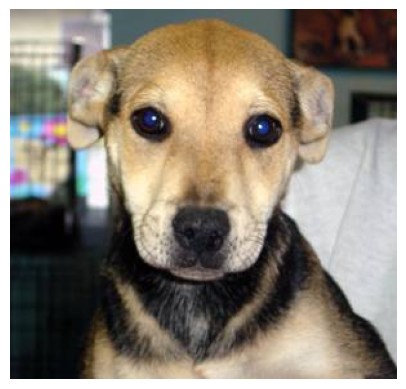

In [2]:
# 원본 이미지 확인
with Image.open(file_path) as img:
    print(f"size of image: {img.size} \n")

    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [3]:
# 이미지 크기 조정
img = img.resize((160, 160))

In [4]:
# 데이터 증강
image_augment = Sequential([
    RandomFlip("horizontal"),   # 수평 뒤집기
    RandomRotation(0.1),   # 회전
    RandomZoom(0.3)   # 확대
])

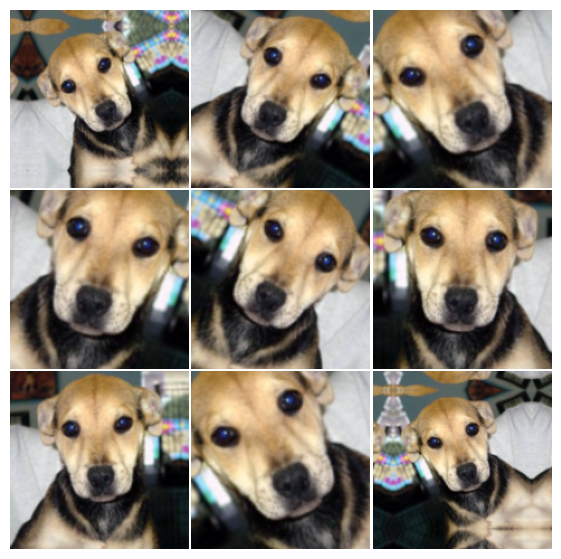

In [ ]:
# 데이터 증강 시각화
plt.figure(figsize=(7, 7))
plt.subplots_adjust(wspace=0.01, hspace=0.01)

for i in range(9):
    augmented_image = image_augment(tf.expand_dims(img, 0))   # 배치 차원 추가
                                     # (batch_size, height, width, channels)
    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image[0] / 255)
    plt.axis("off")

plt.show()

In [ ]:
# 예제 5.3 성능 평가(이진 분류)

# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터셋 준비
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print(x_train.shape, y_train.shape)   # 학습 데이터 shape 확인
print(x_test.shape, y_test.shape)   # 테스트 데이터 shape 확인

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [ ]:
# 레이블 5(sandal)/레이블 7(sneakers) 샘플 추출
index1 = (y_train == 5) | (y_train == 7)
x_train = x_train[index1]   # 학습 데이터

index2 = (y_test == 5) | (y_test == 7)
x_test = x_test[index2]   # 테스트 데아터

# 레이블 재지정
y_train = (y_train[index1] == 7).astype(int)   # 학습 데이터 레이블
y_test = (y_test[index2] == 7).astype(int)   # 테스트 데이터 레이블

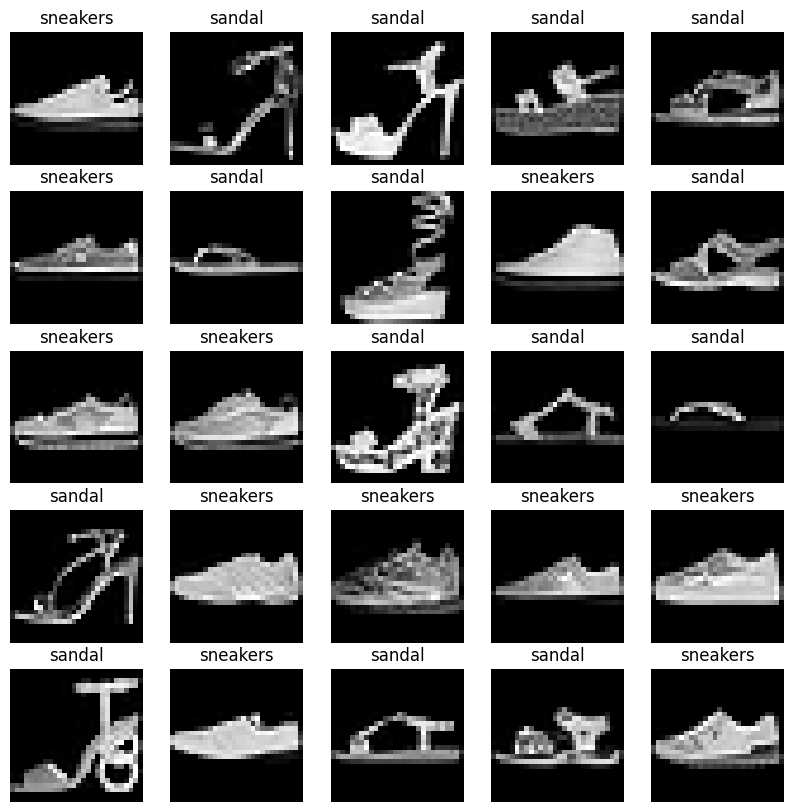

In [ ]:
# 학습 데이터 시각화(클래스명 표시)
class_names = ["sandal", "sneakers"]

plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i].item()])   # 레이블(클래스명) 표시
    plt.axis("off")

plt.show()

In [ ]:
# 데이터 정규화
x_train = x_train / 255
x_test = x_test / 255

In [ ]:
# 모델 생성
inputs = Input(shape=(28, 28))
x = Flatten()(inputs)
x = Dense(16, activation="relu")(x)   # 은닉층 뉴런 16개
outputs = Dense(1, activation="sigmoid")(x)   # 출력층 뉴런 1개

model = Model(inputs, outputs)

In [ ]:
# 모델 컴파일
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [ ]:
# 모델 학습
history = model.fit(x_train, y_train, epochs=5, verbose=0,
                    validation_split=0.2)   # 분할 비율 0.2

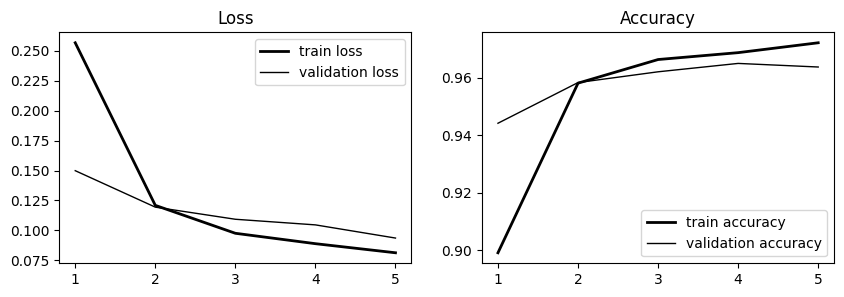

In [ ]:
# 학습 결과 시각화
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(history.history["loss"]) + 1),
         history.history["loss"], label="train loss",
         color="black", linewidth=2)
plt.plot(range(1, len(history.history["val_loss"]) + 1),
         history.history["val_loss"], label="validation loss",
         color="black", linewidth=1)
plt.title("Loss")
plt.legend(loc="best")

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history.history["accuracy"]) + 1),
         history.history["accuracy"], label="train accuracy",
         color="black", linewidth=2)
plt.plot(range(1, len(history.history["val_accuracy"]) + 1),
         history.history["val_accuracy"], label="validation accuracy",
         color="black", linewidth=1)
plt.title("Accuracy")
plt.legend(loc="best")

plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_test: [0 1 0 1 0]
y_pred: [0 1 0 1 0]


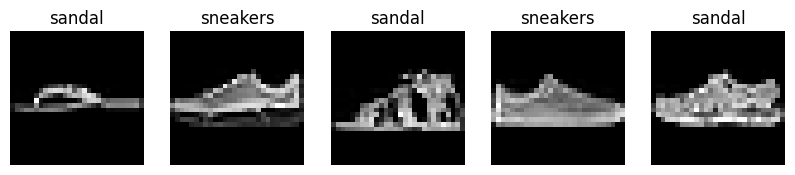

In [ ]:
# 모델 예측(임계치에 따라 0/1 판단)
threshold = 0.5   # 임계치 0.5
y_pred = (model.predict(x_test) >= threshold).astype(int)

print(f"y_test: {y_test[:5]}")   # 테스트 데이터 레이블 확인
print(f"y_pred: {y_pred[:5].reshape(-1)}")   # 예측한 레이블 확인

# 예측 결과 시각화
plt.figure(figsize=(10, 10))

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(class_names[y_pred[i].item()])   # 예측한 클래스명 표시
    plt.axis("off")
plt.show()

accuracy: 0.97
precision: 0.96


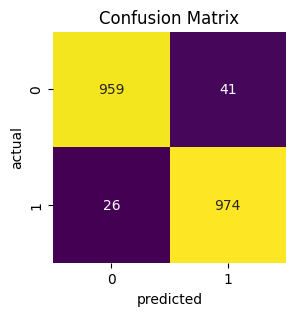

In [ ]:
#성능 평가 지표 출력
print(f"accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"precision: {precision_score(y_test, y_pred):.2f}")

# 혼동 행렬
plt.figure(figsize=(3, 3))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("predicted")
plt.ylabel("actual")

plt.show()